In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict # maybe not
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

RANDOM_SEED = 42

hist_df = pd.read_csv("historical_data.csv")
hist_df.tail()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
11995,11995,7,ad_post,other,rural,android,291.4,2,0,1,93.45,5,21,0,0,0,NaN,0
11996,11996,12,message_send,electronics,urban,ios,64.6,4,0,1,164.86,2,115,0,0,0,98.0,0
11997,11997,11,ad_post,bikes,urban,web,44.4,2,0,2,177.16,2,93,0,0,0,73.8,0
11998,11998,4,message_send,furniture,rural,android,148.5,4,0,0,214.79,1,77,0,0,0,43.5,0
11999,11999,10,message_send,electronics,rural,web,86.6,6,1,0,NaN,4,229,0,0,0,4.3,0


# 1. Dataförståelse

Shape: (12000, 18)

Datatyper: 
id                              int64
day                             int64
event_type                     object
category                       object
region                         object
device                         object
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object

Kolumner med antal blanka värden: 
region                        340
price                         818
time_to_first_response_min    590
dtype: int64

Antal misstänksamma & normala (label):
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Fördelning (labe

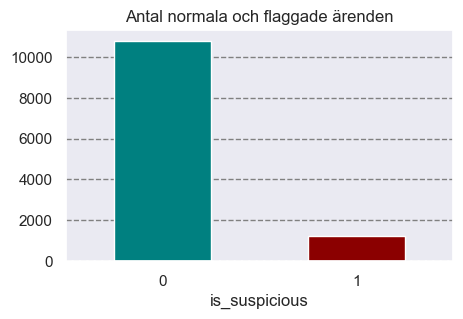

In [3]:
# shape av data:
print(f"Shape: {hist_df.shape}\n")

# dtypes
print(f"Datatyper: \n{hist_df.dtypes}")

missing_vals = hist_df.isna().sum()
print(f"\nKolumner med antal blanka värden: \n{missing_vals[missing_vals>0]}")

# fördelning i label
label_count = hist_df["is_suspicious"].value_counts()
label_ratio = hist_df["is_suspicious"].value_counts(normalize=True)
print(f"\nAntal misstänksamma & normala (label):\n{label_count}")
print(f"\nFördelning (label): \n{label_ratio}\n")

plt.figure(figsize=(5,3))
label_count.plot(kind="bar",color=["teal","darkred"])
plt.xticks(rotation=0)
plt.title("Antal normala och flaggade ärenden")
plt.grid(False, axis="x")
plt.grid(True, axis="y", linestyle="--",c="gray")
plt.show()

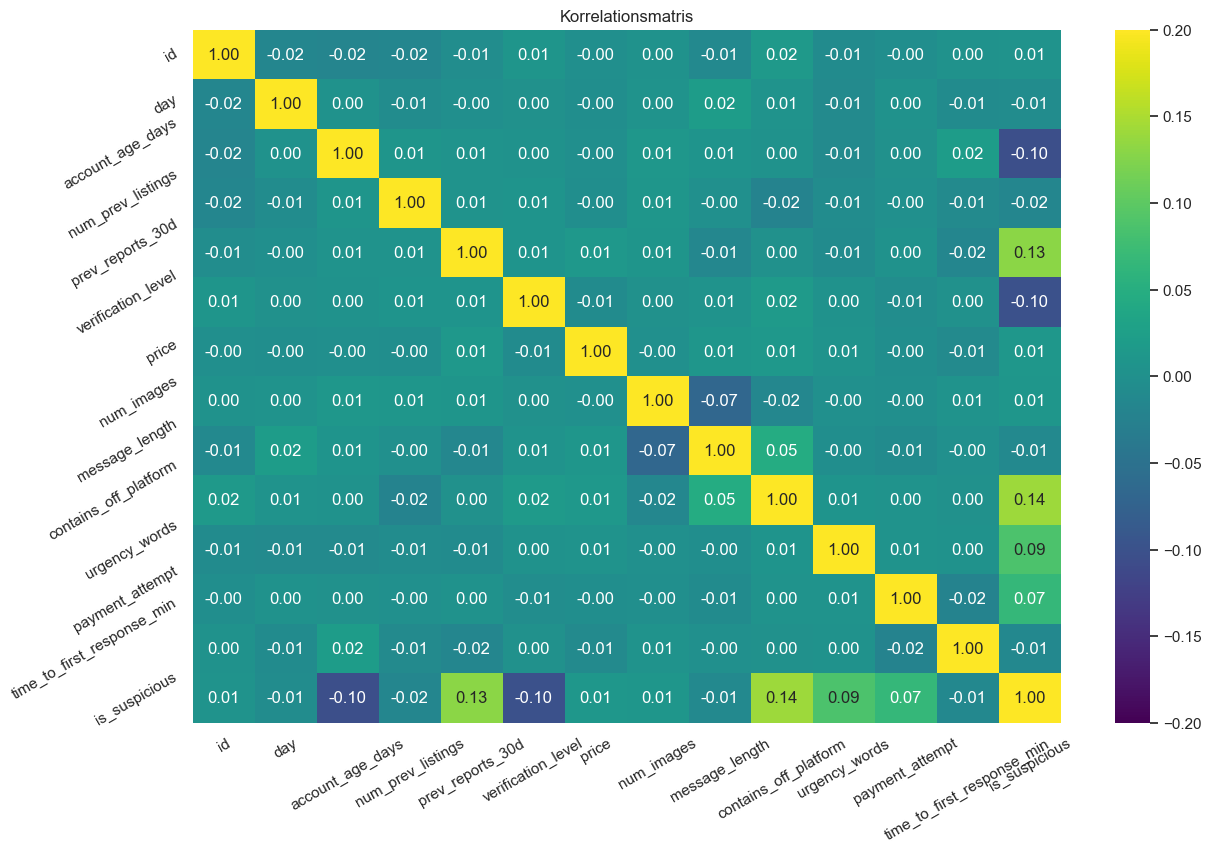

In [4]:
plt.figure(figsize=(14,9))
corr_matrix = hist_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis",vmax=0.2,vmin=-0.2)
plt.title("Korrelationsmatris")
plt.xticks(rotation=30)
plt.yticks(rotation=30)
plt.show()

# satte vmax och vmin för bättre färgskala.

I stapelgrafen med fördelning av normala & flaggade ärenden var $10,776 \ (89.9\%)$, inte misstänksamma av $12,000$.

En modell som alltid gissar icke-misstänkt skulle därför få cirka $90\%$ *accuracy*, men missa varje misstänkta ärende; en oönskad konsekvens.

*Precision* säger andelen sanna positiva över falska plus sanna positiva flaggningar (d.v.s. andel äkta misstänkta), och *recall* andelen sanna misstänkta över sanna plus missar (d.v.s. problemfångst).

Balansgången av precision och recall mäts av *F1*.

Korrelationsmatrisen visar inflytande emellan features. Kolumnerna `account_age_days` och `verification_label` är negativt korrelerade mot label (`is_suspicious`). Största positiva korrelationerna mot label är `contains_off_platform`,  `prev_reports_30d` och `urgency_words`. Säkerhetstänk eller teori i dessa korrelationer matchar.

# 2. Train/test & preprocessing

In [5]:
X = hist_df.drop("is_suspicious", axis=1) # features
y = hist_df["is_suspicious"] # label

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y)

print(f"X_train shape: {X_train.shape}, y_test shape: {y_test.shape}")

proportion_ytest = y_test.value_counts(normalize=True)
print("\nFördelning i test:\n", proportion_ytest.round(3))

X_train shape: (9600, 17), y_test shape: (2400,)

Fördelning i test:
 is_suspicious
0    0.898
1    0.102
Name: proportion, dtype: float64


In [6]:
cat_feat = X_train.select_dtypes(exclude=["number"]).columns.to_list()
num_feat = X_train.select_dtypes(include=["number"]).columns.to_list()
expected_cols = X_train.columns.tolist()


# gör kolumner med NaN ifall de inte finns i "new_data.csv" senare.
# output: en df med rätt-arrangerade columns + ifyllda NaN ifall column missing.
#
def align_to_scema(df_new: pd.DataFrame, expected_cols: list[str]) -> pd.DataFrame:
    df_aligned = df_new.copy()
    for col in expected_cols:
        if col not in df_aligned.columns:
            df_aligned[col] = np.nan
    return df_aligned[expected_cols]


# Pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_feat),
        ("cat", categorical_transformer, cat_feat)
    ],
    remainder="drop"
)

# 3. Modellering & jämförelse

In [7]:
models = {
    "Baseline": DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED),
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_SEED)
}

compare_models = [] # lagra resultat

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocess), #  imputer och standardscaler / OHE
        ("model", model)
    ])

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    # Lagra medelvärde per fold
    #  Tar inte med accuracy pga fokus på falsklarm
    compare_models.append({
        "Model": name,
        "Precision_mean": cv_scores["test_precision"].mean(),
        "Precision_std": cv_scores["test_precision"].std(),
        "Recall": cv_scores["test_recall"].mean(),
        "F1": cv_scores["test_f1"].mean(),
        "ROC_AUC": cv_scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(compare_models).sort_values(by="Precision_mean", ascending=False)

print("Cross validation av 4 modeller:")
display(np.round(cv_df,4))


Cross validation av 4 modeller:


,Model,Precision_mean,Precision_std,Recall,F1,ROC_AUC
1,Logistic Regression,0.5843,0.1323,0.0439,0.0814,0.7384
4,Gradient Boosting,0.5315,0.0260,0.0705,0.1243,0.7558
3,Random Forest,0.4557,0.1164,0.0092,0.0180,0.7326
2,Decision Tree,0.1832,0.0171,0.2124,0.1966,0.5525
0,Baseline,0.0000,0.0000,0.0000,0.0000,0.5000


Översta modellen har högst precision *mean* & låg *std*, vilket önskas i *operations* då flaggningar blir pålitliga (då andelen falsklarm blir liten kontra rätta larm).

Logistic regression fångar linjära samband väl. Gradient boosting hade högre *std*, och random forest hade 13% lägre precision än logistic regression.

# 4. Hyperparameter-tuning

In [8]:
winner_model = models["Logistic Regression"]
winner_pipe  = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("model", winner_model)
])

winner_pipe

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
# Hyperparameter grid
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2", "l2"],
    "model__class_weight": [None, "balanced"],
    # "preprocess__num__imputer__strategy": ["median","mean"] # GER ERROR
    "model__solver": ["liblinear", "lbfgs"]
}

# GridSearchCV konfigurering
grid_search = GridSearchCV(
    estimator = winner_pipe,
    param_grid = param_grid,
    cv = cv,
    scoring = "precision",
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

print("Optimerade hyperparametrar:")
print(grid_search.best_params_)
print(f"\nHögsta Precision enl. CV: {grid_search.best_score_:.4f}")

tuned_winner_model = grid_search.best_estimator_ # lagra


Optimerade hyperparametrar:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Högsta Precision enl. CV: 0.6746


Modellen optimeras i:
* $C$ för komplexitet (enkel modell: mindre overfit),
* Klassvikt $None$ (modellen särskiljer klasserna bra med 90/10 ration),
* Bromsning $L2$ (tryckar inte koefficienter till 0 helt, så modellen inte övertolkar brus),
* Solver *liblinear* (optimerat för binära klassningar).

Resultat; låg komplexitet, klassvikt inte extrem, $L2$ jämn koefficient krympning (sparar information vs. L1 som krymper till $0$), och solvern liblinear utpresterade lbfgs (multinomiell).

In [ ]:
# tuned logistic regression på X_test & y_test:
# (bra för jämförelse med top-5%)

y_pred = tuned_winner_model.predict(X_test)
y_proba = tuned_winner_model.predict_proba(X_test)[:, 1]

print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {np.round(recall_score(y_test, y_pred),4)}")
print(f"F1: {np.round(f1_score(y_test, y_pred),4)}")
print(f"ROC-AUC: {np.round(roc_auc_score(y_test, y_proba),4)}")
print(f"\nFörvirringsmatris:\n{confusion_matrix(y_test, y_pred)}")

# visa vad vi fick i CV igen:
display(cv_df[cv_df["Model"] == "Logistic Regression"])

Precision: 0.625
Recall: 0.0204
F1: 0.0395
ROC-AUC: 0.7356

Förvirringsmatris:
[[2152    3]
 [ 240    5]]


,Model,Precision_mean,Precision_std,Recall,F1,ROC_AUC
1,Logistic Regression,0.584314,0.132276,0.04393,0.081375,0.738354


# 5. Prioritering
Vi valde att applicera top-5% ovanpå logistic regression. Följt av kravkortet (Ali, Operations) behövs begränsad arbetsmängd varje dag, inte en kö med ärenden som byggs upp.

Vi visar hur vårat beslut av TOP-X påverkar *FalsePositive och FalseNegative* (confusion matrix).

In [ ]:
# 1. Förståelse av top-5% i X_test
top_5_percent = 0.05
rows_per_day = hist_df['day'].value_counts().sort_index() #ascending=False
historic_data_rows = pd.DataFrame({
    "ärenden/dag": rows_per_day,
    "top-5%/dag": (rows_per_day*0.05).astype(int)
})
print("Såhär många ärenden per dag, och 5% av dem, är i historic_data:")
print("Visar bara 3 översta raderna.")
display(historic_data_rows.head(3))


top5perc_testdf = pd.DataFrame({
    "day": X_test['day'],
    "y_proba": y_proba,
    "y_true": y_test.values
})

top5perc_testdf['daily_ranking'] = (
    top5perc_testdf.groupby('day')['y_proba'].rank(method='first',ascending=False)
)
print("\n")
print("Här är 3 högst misstänksamma raderna i dag 1 (i X_test):")
print("Notera att lägre rank är större misstänksamhetsgrad.")
display(top5perc_testdf[top5perc_testdf['day'] == 1].sort_values('daily_ranking').head(3))
# färdig med förståelse av top-5% i X_test.

# bonus-förklaring: 12,000 rader, 14 dagar, top5% / dag = 40-45st.
#         test(20%): 2,400 rader, 14 dagar, top5% / dag = 8-9st.


# förvirringsmatris top-5% per dag i X_test:
top5perc_testdf['top5perc_per_day'] = (
    top5perc_testdf.groupby('day')['y_proba'].transform(
        lambda x: max(1, int(len(x) * 0.05))))


top5perc_testdf['top5perc_flag'] = (top5perc_testdf['daily_ranking'] <=
                                    top5perc_testdf['top5perc_per_day'])

print("\n\nHär är tabell (översta 5 raderna) som visar radnummer, och rank-krav för top5%:")
display(top5perc_testdf.head())
print("\n")


# förvirringsmatris från optimerad logistic regression (för jämförelse):
print("------------------------------------------------------")
print("Förvirringsmatris från optimerad logistic regression:")
print(confusion_matrix(y_test, y_pred))


# 2. top-5% för y_test
y_pred_top5perc = np.int64(top5perc_testdf['top5perc_flag'])
print("\nFövirringsmatris för top-5%:\n",confusion_matrix(y_test, y_pred_top5perc))

Såhär många ärenden per dag, och 5% av dem, är i historic_data:
Visar bara 3 översta raderna.


,ärenden/dag,top-5%/dag
day,,
1,857,42
2,859,42
3,885,44




Här är 3 högst misstänksamma raderna i dag 1 (i X_test):
Notera att lägre rank är större misstänksamhetsgrad.


,day,y_proba,y_true,daily_ranking
7671,1,0.462420,0,1.0
5789,1,0.341424,0,2.0
7186,1,0.337628,0,3.0




Här är tabell (översta 5 raderna) som visar radnummer, och rank-krav för top5%:


,day,y_proba,y_true,daily_ranking,top5perc_per_day,top5perc_flag
3011,2,0.118663,1,47.0,8,False
7375,3,0.068037,0,131.0,9,False
2270,5,0.144990,0,38.0,8,False
11988,10,0.033072,0,157.0,8,False
10738,4,0.109932,1,49.0,7,False




------------------------------------------------------
Förvirringsmatris från optimerad logistic regression:
[[2152    3]
 [ 240    5]]

Fövirringsmatris för top-5%:
 [[2084   71]
 [ 204   41]]


Optimerad (mot precision) logistic regression använder tröskeln 0.5 för klassningarna, och gjorde 3 falsklarm och 240 missar, med bara 5 sanna positiva.

Top-5% per dag går inte med tröskel 0.5, det blir mindre försiktigt och ger 71 falsklarm & 36 färre missar, medan 36 flera sanna positiva.

Det blir flera falsklarm med top-5%, men mer misstänkt aktivitet blir identifierad korrekt, vilket är att föredra i *operations* (top-50 ärenden skulle låsa arbetsmängden mera, möjligtvis).

# 6. Deploy-test

Skapa en låst pipeline, och kör på "new_data.csv" tisdag 16/3.

Vi ska skapa prediktioner och prioriteringslista.

In [12]:
# Vi använder joblib för att spara en pipeline (föreläsning 18)
import joblib

# spara optimerad logistic regression
joblib.dump(tuned_winner_model, "lock_pipe.joblib")
lock_pipe = joblib.load("lock_pipe.joblib")

# hämta in new_data.csv
new_df = pd.read_csv("new_data.csv")
new_data_aligned = align_to_scema(new_df, expected_cols)

# kör logistic regression
new_pred = lock_pipe.predict(new_data_aligned)
new_proba = lock_pipe.predict_proba(new_data_aligned)[:,1]

deployed_df = new_df.copy()
deployed_df['predicted_target'] = new_pred
deployed_df['y_proba'] = new_proba

# rank och top-5% per dag
deployed_df['daily_ranking'] = deployed_df.groupby('day')['y_proba'].rank(
    method='first', ascending=False)

deployed_df['top5perc_per_day'] = (
    deployed_df.groupby('day')['y_proba'].transform(
        lambda x: max(1, int(len(x) * 0.05))))

deployed_df['top5perc_flag'] = (deployed_df['daily_ranking'] <=
                                deployed_df['top5perc_per_day'])

#   "new_data.csv" kommer inte ha kolumnen is_suspicious,
#     (så förvirringsmatris blir uteslutet).

priorities = deployed_df[deployed_df['top5perc_flag']].copy()
priorities = priorities.sort_values(['day', 'daily_ranking'])

print("Hur många ärenden i new_data är prioriteter:", len(priorities))
print("Urval av prioriteter:")
display(priorities.head(10))

print("\nKronologiskt - prioriteter:")
display(priorities['day'].value_counts().sort_index())



# Vi ska ha med deploy-test resultat i Presentation.

FileNotFoundError: [Errno 2] No such file or directory: 'new_data.csv'

## Deploy-test resultat:

Utan `is_suspicious` kan vi inte ta fram förvirringsmatris eller metrics-värden. Låst pipeline (logistic regression optimerad mot precision) förutspår procents chans för misstänksamhet i *new_data.csv* raderna, och top-5% låter oss ta fram prioriterade ärenden till *operations*-avdelningen så de kan granskas.

Modellen är tränad på X_train från *historic_data.csv* och kan deployas dagligen för att ta fram misstänksam aktivitet, där mängden beror på totala dagliga aktiviten (inte låst till antal), teamet får se hur mycket de hinner med.

*Operations* kan använda prioritetslistan, men behov för omträning av data eller undersökning av fortsatt välfungerande av modellen är inte en uppgift för drift-teamet.

In [ ]:
#   To be done tisdag 16/3.



# resultat av deployed logistic regression + top-5% på "new_data.csv":
#
#
# ...